<a href="https://colab.research.google.com/github/Elpog1/EMSC2010-Seismic-Babes-Project-5/blob/main/EMSC2010_Group_Project_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Group Project 5

## 1. Project Overview
Group name: Seismic Babes

Project week: 10

Project title: Solar Cycles

Datasets used (name and source): Solar Influences Data Analysis Center (SILSO) (https://www.sidc.be/SILSO/datafiles)

## 2. Roles and contributions

| Role | Primary | Deputy | Completed? | Notes |
| :--- | :--- | :--- | :--- | :--- |
| Github & integration | Eloise | Freddie | Yes| Add note|
| Data steward | Justin | Eloise | Yes| Add note|
| Analysis / modelling | Ed | Justin | Yes| Add note|
| Visualisation / interpretation | Owen | Ed | Yes| Add note|
| Narrative | Clover | Owen | Yes| Add note|
| Quality Control / Reproducibility  | Freddie | Clover | Yes| Add note|


# Question

Can we detect, measure, and characterise the solar cycle from 275 years of observations?

# Data Import: Justin

### Problem framing
In this notebook we'll use the Fourier transform to analyse the international sunspot number record spanning the last 275 years.


Sunspots are dark regions on the surface of the Sun caused by intense localised magnetic activity. The number of sunspots visible at any given time is not constant, it rises and falls in a roughly regular cycle driven by changes in the Sun's magnetic field.


This cycle has important consequences for Earth. During periods of high sunspot activity the Sun emits more energy and charged particles, which can affect satellite communications, power grids, and even climate. Detecting and characterising this cycle from the observational record is therefore an important problem in Earth and space science.





## Scope

##FAIR DATA SECTION

**Findability (F):**

The international sunspot number dataset is published and maintained by the Solar
Influences Data Analysis Center (SILSO) at the Royal Observatory of Belgium. The
dataset is freely accessible online at https://www.sidc.be/SILSO/datafiles

**Accessibility (A):**

The data is openly available for download  directly from the SILSO website
without requiring an account or login. It is provided in plain text CSV format. I have attached the url to the data file used in this analysis.

See attahced data file in GitHub (URL)!!

**Interoperability (I):**

The dataset is provided in a plain text CSV format using semicolon delimiters, which
can be opened by most imports such as numpy or pandas. The csv file containes both year/month columns and as a decimal year value. Additoanly the observtions has corresponidign standard diviation and additonatl meta data.


**Reusability (R):**

The dataset is published under a Creative Commons licence, meaning it
can be freely shared and reused for non-commercial purposes (including education)

provided appropriate credit is given. The recommended citation is:

The Royal Observatory of Belgium undertakes to make this site accessible, in accordance with the following legislation: Law of 19 July 2018 relating to the accessibility of websites and mobile applications of public sector bodies .

This accessibility statement applies to the website  https://www.astro.oma.be


please see terms of use within SILSO

(https://www.astro.oma.be/en/information/terms-use/)

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Importing data via URL from GitHub
url = 'https://raw.githubusercontent.com/Elpog1/EMSC2010-Seismic-Babes-Project-5/refs/heads/main/SN_m_tot_V2.0.csv'
df = pd.read_csv(url,sep=';',header=None, names=['year','month','decimal_year','sunspot_num','std','n_obs','flag'])
print(df.head(5))

### redundancy if url is broken
# df = pd.read_csv('/content/SN_m_tot_V2.0.csv',sep=';',header=None, names=['year','month','decimal_year','sunspot_num','std','n_obs','flag'])
# print(df.head(5))

   year  month  decimal_year  sunspot_num  std  n_obs  flag
0  1749      1      1749.042         96.7 -1.0     -1     1
1  1749      2      1749.123        104.3 -1.0     -1     1
2  1749      3      1749.204        116.7 -1.0     -1     1
3  1749      4      1749.288         92.8 -1.0     -1     1
4  1749      5      1749.371        141.7 -1.0     -1     1


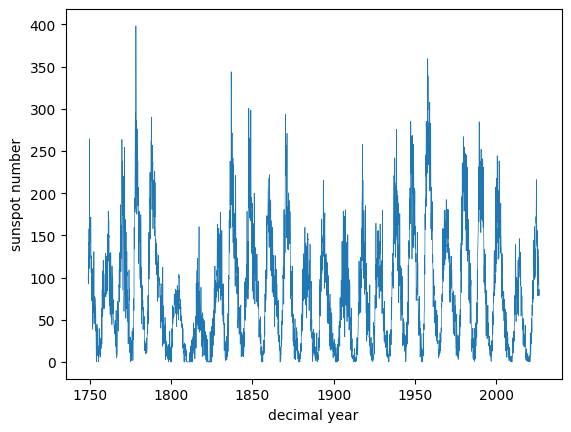

In [12]:
### analysis plot raw data
year = df['decimal_year']
sunspot_num = df['sunspot_num']


plt.plot(year,sunspot_num, markersize=0.5,linewidth=0.5)
plt.xlabel('decimal year')
plt.ylabel('sunspot number')
plt.show()

# Data Analysis: Ed

Define functions:
*   ```freq_spectrum```: calculates the frequency spectrum for a signal.
*   ```lowpass_filter```: will remove frequencies higher than ```cutoff```.
*   ```highpass_filter```: will remove frequencies lower than ```cutoff```.

In [13]:
def freq_spectrum(time,signal):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT (positive freqs only)
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  # Amplitude: scale by 2/n so each peak height equals the true amplitude
  amplitude = (2 / n) * np.abs(fft_vals)
  amplitude[0] /= 2

  return freqs, amplitude

def lowpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs>cutoff] = 0.0 #cycles above the frequency cutoff are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal


def highpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs<cutoff] = 0.0 #cycles below the frequency cutoff are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal

def bandpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs<cutoff[0]] = 0.0 #cycles below cutoff[0] are given an amplitude of 0
  fft_vals[freqs>cutoff[1]] = 0.0 #cycles above cutoff[1] are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal

Calculate and plot the frequency spectrum.

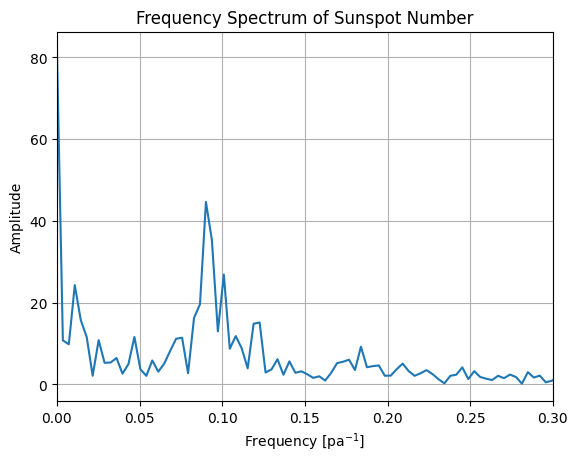

In [14]:
freqs, amplitude = freq_spectrum(year, sunspot_num)
plt.plot(freqs, amplitude)
plt.xlabel('Frequency [pa$^{-1}$]')
plt.ylabel('Amplitude')
plt.xlim([0,0.3])
plt.title('Frequency Spectrum of Sunspot Number')
plt.grid(True)
plt.show()

This plot shows the frequency spectrum of the sunspot number data. The x-axis represents the frequency in cycles per year, and the y-axis represents the amplitude of those frequencies. Peaks in this plot indicate dominant periodicities in the sunspot activity. For instance, a prominent peak around 0.09 cycles/year would correspond to the approximately 11-year solar cycle (1/0.09 ≈ 11.1 years).

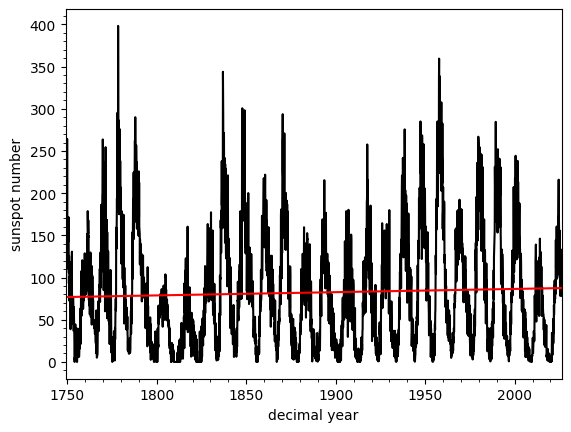

In [15]:
pp = np.polyfit(year,sunspot_num,1) #fit a trendline to the data
plt.plot(year,sunspot_num,'k') #plot the original data
plt.plot(year,np.polyval(pp,year),'r') #plot the trendline
plt.xlabel('decimal year') #label the x-axis
plt.ylabel(r'sunspot number') #label the y-axis
# plt.gca().invert_yaxis() #invert the y-axis
plt.xlim([min(year),max(year)]) #limit the x-axis to the actual data range
plt.minorticks_on() #add minorticks

The detrended data conveys the original data minus the fitted line, we will calculate it's frequency spectrum.


Plot vertical lines at frequencies corresponding to sunspot cycles.

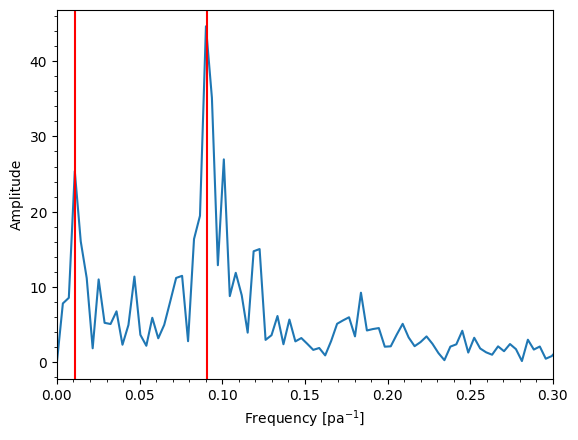

In [16]:
detrend = sunspot_num-np.polyval(pp,year) #calculate the detrended data
freqs, amps = freq_spectrum(year,detrend) #frequency spectrum of the detrended data
plt.plot(freqs,amps) #plot the frequency spectrum
plt.xlabel('Frequency [pa$^{-1}$]') #label the x-axis
plt.ylabel('Amplitude') #label the y-axis
plt.xlim([0,0.3]) #limits the x-axis
plt.minorticks_on() #add minorticks

plt.gca().axvline(x=1/90,color='r') #mark gleissberg frequency
plt.gca().axvline(x=1/11,color='r') #mark solar frequency

We can see a clear expression of sunspot cycles in the data.


11 year __Solar cycle__ and ~80-100 year __Gleissberg cycle__.

We want to isolate certain frequency components of the signal to represent the contribution of different sunspot cycles. We can use ```lowpass_filter```to isolate the gleissberg cycle component by removing the higher frequency component (solar cycle).

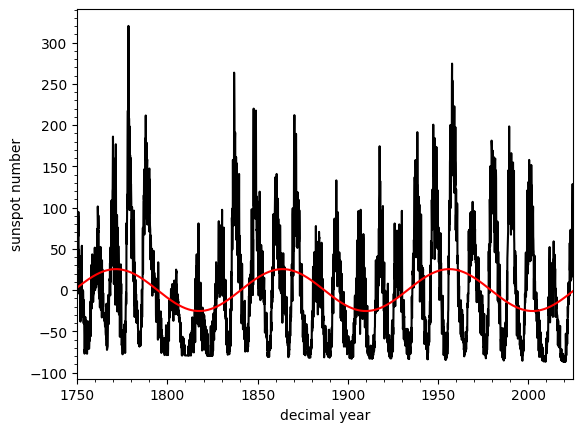

In [17]:
plt.plot(year,detrend,'k') #plot the detrended data
x, y = bandpass_filter(year,detrend,[1/100,1/80]) #obtain the filtered signal
plt.plot(x,y,'r') #plot the filtered signal
plt.xlabel('decimal year') #label the x-axis
plt.ylabel(r'sunspot number') #label the y-axis
plt.xlim([1750,2025]) #limit the x-axis
plt.minorticks_on() #add minorticks

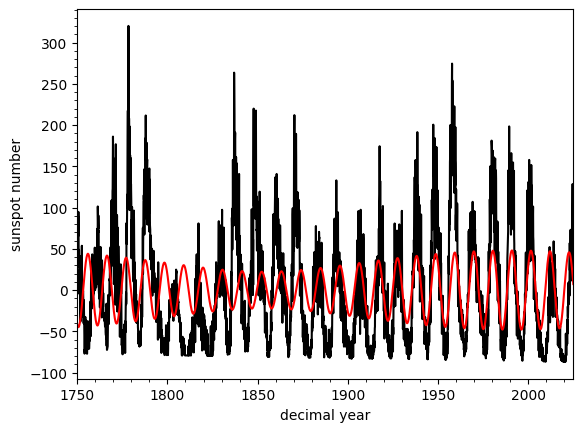

In [18]:
plt.plot(year,detrend,'k') #plot the detrended data
x, y = bandpass_filter(year,detrend,[1/11,1/10]) #obtain the filtered signal
plt.plot(x,y,'r') #plot the filtered signal
plt.xlabel('decimal year') #label the x-axis
plt.ylabel(r'sunspot number') #label the y-axis
plt.xlim([1750,2025]) #limit the x-axis
plt.minorticks_on() #add minorticks

Applying a bandpass filter for the **solar cycle** of `[1/11, 1/10]`,  allowing frequencies between approximately 0.09 and 0.1 to pass through. For the **Gleissberg cycle**  the bandpass filter is `[1/100, 1/80]` cycles/year, allowing frequencies between 0.01 and 0.0125.

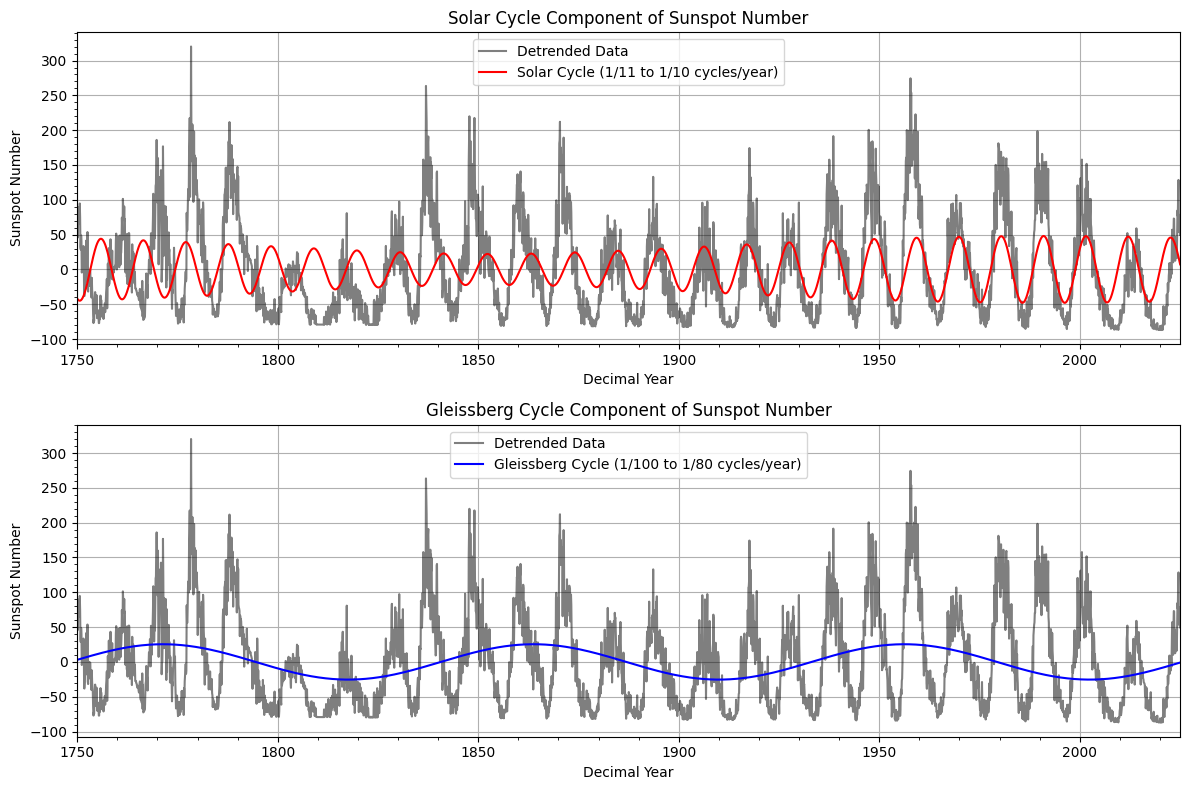

In [19]:
# Apply bandpass filter for the Solar Cycle (~11 years)
x_solar, y_solar = bandpass_filter(year, detrend, [1/11, 1/10])

# Apply bandpass filter for the Gleissberg Cycle (~80-100 years)
x_gleissberg, y_gleissberg = bandpass_filter(year, detrend, [1/100, 1/80])

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(year, detrend, 'k', label='Detrended Data', alpha=0.5)
plt.plot(x_solar, y_solar, 'r', label='Solar Cycle (1/11 to 1/10 cycles/year)')
plt.xlabel('Decimal Year')
plt.ylabel('Sunspot Number')
plt.title('Solar Cycle Component of Sunspot Number')
plt.xlim([1750, 2025])
plt.minorticks_on()
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(year, detrend, 'k', label='Detrended Data', alpha=0.5)
plt.plot(x_gleissberg, y_gleissberg, 'b', label='Gleissberg Cycle (1/100 to 1/80 cycles/year)')
plt.xlabel('Decimal Year')
plt.ylabel('Sunspot Number')
plt.title('Gleissberg Cycle Component of Sunspot Number')
plt.xlim([1750, 2025])
plt.minorticks_on()
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#Data Visualisation - Owen

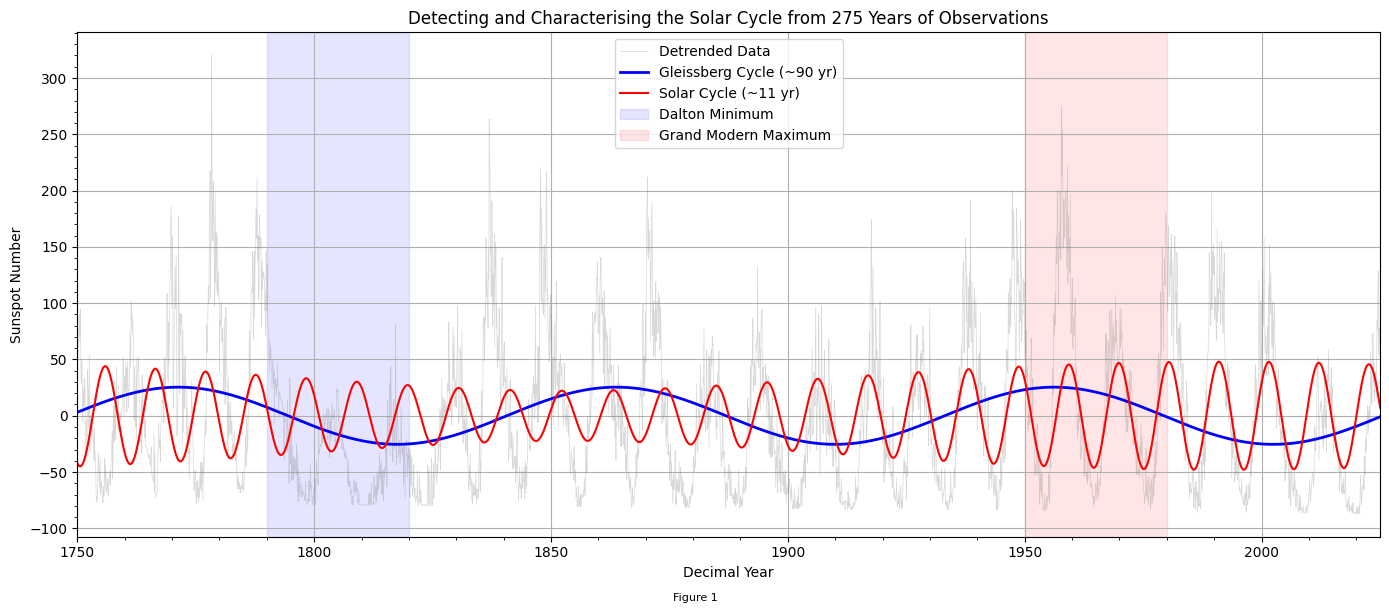

In [20]:
# Summary plot - combining all findings
fig, ax = plt.subplots(figsize=(14, 6))

# Raw detrended data
ax.plot(year, detrend, 'grey', alpha=0.3, linewidth=0.5, label='Detrended Data')

# Gleissberg cycle
ax.plot(x_gleissberg, y_gleissberg, 'b', linewidth=2, label='Gleissberg Cycle (~90 yr)')

# Solar cycle
ax.plot(x_solar, y_solar, 'r', linewidth=1.5, label='Solar Cycle (~11 yr)')

# Annotations
ax.axvspan(1790, 1820, alpha=0.1, color='blue', label='Dalton Minimum')
ax.axvspan(1950, 1980, alpha=0.1, color='red', label='Grand Modern Maximum')

ax.set_xlabel('Decimal Year')
ax.set_ylabel('Sunspot Number')
ax.set_title('Detecting and Characterising the Solar Cycle from 275 Years of Observations')
ax.set_xlim([1750, 2025])
ax.minorticks_on()
ax.legend()
ax.grid(True)
plt.figtext(0.5, -0.01, "Figure 1", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

# Interpretation
### Model Interpretation
The Fourier transform allowed us to separate overlapping periodic signals in the sunspot record by converting the data from the time domain into the frequency domain. While the ~11-year Schwabe cycle dominated the raw data, the FFT revealed both the 11-year cycle and the longer ~90-year Gleissberg cycle as distinct peaks in the frequency spectrum. Bandpass filtering then allowed each cycle to be isolated and reconstructed through time.

This showed that the strength of the 11-year cycle changes over time and appears to be modulated by the Gleissberg cycle. Periods associated with positive Gleissberg phases produced stronger solar maxima, while negative phases corresponded to weaker activity. Interpolation onto an evenly spaced grid and removal of linear trends also improved the clarity of the spectrum by reducing distortion and low-frequency noise, making weaker long-period signals easier to detect.

### Physical Interpretation
The dominant signal in the dataset is the ~11-year solar cycle, which reflects periodic changes in the Sun’s magnetic activity and polarity reversal. This cycle produced the clearest peak in both the raw data and the frequency spectrum, confirming it as the primary driver of short-term solar variability.

The longer ~90-year Gleissberg cycle appears to control the strength of successive 11-year cycles over time. Constructive interaction between the two cycles is associated with periods of unusually strong solar activity, such as the Grand Modern Maximum, while destructive interaction may contribute to weaker periods like the Dalton Minimum. These long-term variations are important because they influence space weather, geomagnetic activity, and potentially Earth’s climate system.

### Limitations

A major limitation of this analysis is the relatively short dataset compared to the length of the Gleissberg cycle. Although the record spans ~275 years, this only captures around three full ~90-year cycles, making it difficult to confidently confirm long-period behaviour. Earlier observations before the mid-1800s are also less reliable due to fewer observers and less accurate instruments, which may introduce noise into the analysis.

The FFT also assumes cycles are perfectly regular and stationary, whereas the solar cycle actually varies between roughly 9–13 years and changes in amplitude over time. Additionally, the bandpass filter cut-off frequencies were selected manually, meaning different choices could slightly alter the reconstructed cycles. Lower-quality historical data points were retained to preserve continuity, but these may also reduce the accuracy of the resulting spectra and filtered signals.

# Reflections

---


## Eloise

Whilst my role this week was important in allowing the rest of my group to complete their roles, it was relatively simple as I did not have to do any working with data, coding, visualisation, or narrating. However, I am glad for this role as it has allowed me to gain extra practice in managing github repositories and notebooks. The tasks completed in my role included setting up the repository from the template then opening the colab notebook in drive so my group members could begin editing, which was easy as we have done this many times in class. On Thursday I checked the notebook ran correctly, added the excel data file into the repository, and also changed the URL for the data import to be that of the raw data from the excel file I had just added. Completing these tasks was necessary in allowing the final code to run before I could commit the notebook to github. Overall, I feel as though I completed my role to a satisfying degree and am very grateful to my group members for bringing together a cohesive and well thought-out project.  

---


## Justin

My role this week as data steward was really about managing expectations during the final weeks of the semester. The team didn't necessarily have any concrete ideas leaving the Friday workshop, so doing some research and finding a clean dataset that would work for this week's project was a good challenge. It allowed me to critically think about what we were looking to achieve and how we would go about it, prompting a bit of extra research into other forms of filtering along the way. A major benefit of this role was integrating the FAIR principles into the document, as well as establishing a working URL for easy data integration, which I am hopeful will work smoothly. Overall, this group project has been a fantastic collaborative learning experience. Working with many different perspectives and ideas has opened my eyes to data science. It has given me the skills necessary to take on different tasks and questions, the ability to apply what we have learned from this semester's coursework, and the confidence to learn new data analysis techniques in the future.


---

## Ed

My role this week as data analyst was very straightforward. I can say this thanks Justin's data selection and formatting in his role as data steward. The topic was perfect for running a Fournier transform. I applied the same method to this sunspot data as was applied to the Milankovitch cycles in class. I am grateful for the conscientious nature of my group which has meant I could learn something from every member. Through my own shortcomings in some roles and through observing quality work from my group members I have improved my own literacy and techniques regarding identifying problems and applying different strategies to extract data.

---


## Owen
This week, I was tasked with visualising our results, and assisting with the interpretation of the models we used, the physical results, and limitations with our experiment. The visualisation component was a fairly straightforward task and essentially required me to compile the work of some of my other group members into one easy-to-read graph, that properly represented our findings and made it easier to relate to our original question and hypothesis. Furthermore, my interpretation section required me to outline some talking points that Freddie and Clover would develop further. This required an in-depth understanding of the processes inside our code, the meaning behind our use of the models we learnt about in class, and a close eye to identify the limitations in our data and design. Overall, this was the most difficult component of my task this week, however I believe I set a solid framework that could be developed further into a succinct and sound interpretation of our project.

---
## Clover

Having a role that is more uninvolved until the last stages of the project has made me appreciate the work of my group members. For this project everyone did really well with the flow of data import, analysis, visualisation, etc. I feel that we have reached a highly functioning flow especially in terms of making sure the individual steps are easily understandable - this allowed me to easily jump in and understand this topic from the lens of class content. I focused on the readability and cohesion of the file, adding some important details in the project overview and introduction and working on the interpretation section which Owen outlined. Overall this sun spot topic proved to be an clear application of frequency analysis and a great example of our group cohesion.

---


## Freddie

As quality control this week, I was one of the last people to get their hands on the project. My role was to ensure all parts of the code were flowing very smoothly. I had a thourough read-through of the project to ensure that (a) I understood everything and (b) There were no major errors. Once again, with this being one of the last group projects, we have entered a sort of flow-state, where everyone knows what their role is and how best to achieve it. We are at the point where we are all relatively confident with all elements of this process so it is very easy going. My role was very important to ensure that all elements were running correctly, which they were thanks to my amazing team mates. This week has made me reflect upon our first project where we were slightly lost, thankfully that has gone away. We have still kept up the habit of accidentally choosing very difficult projects (A theme we have tried to avoid this week), however in the long run that has improved our skills. Overall, this week's project ran smoothly and I didn't need to make any major changes apart from the odd sentence fix here or there.


---